<a href="https://colab.research.google.com/github/me1-3/Emsc2010-A3/blob/main/Another_copy_of_EMSC2010_Group_Project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project template

## 1. Project Overview
Group name: Ocean's Eleven Variables

Project week: 3 (Week 8)

Project title: Bayesian regression modelling of changing coral cover on the Barnards and Barren reefs

Datasets used (name and source):
Clean Data = https://anu365-my.sharepoint.com/:x:/g/personal/u7447903_anu_edu_au/IQBt9qZwAzaOS6-ceDOK3EkiAagFt_hNsHY_hrUc6nCgTfo?e=qZ4i6k

Raw Data = https://anu365-my.sharepoint.com/:x:/g/personal/u7447903_anu_edu_au/IQB65BOLJE4tRK1CQQifi2jmAZCTozxZvPZSyoedVcb_t98?e=InfRXL

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Charlotte | Leo | Yes| Add note|
| Data steward | Leo | Jiah | Yes| Add note|
| Analysis / modelling | Jiah | Emily | Yes| Add note|
| Visualisation / interpretation | Emily | Mel | Yes| Add note|
| Narrative | Mel | Georgia | Yes| Add note|
| Quality Control / Reproducibility  | Georgia | Charlotte | Yes| Add note|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected:

* Reason (e.g. missed deadline, absence, etc.):

* Deputy action taken:

* Impact on workflow:

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

AIM:

Our aim for this project was to use Bayesian regression modelling to see how coral reef cover changes over time for two different reef locations; Barnards and Barren, tracking to see if there was a consistent trend in coral cover and if it differed in-between reef types.


DATA PREPARATION & COLLECTION: https://www.bco-dmo.org/dataset/990924

The data was extrapolated from publically available AIMS monitoring programs in the Great Barrier Reef (data is linked above). The reef is divided into many smaller areas across the, some of which we excluded due to lack of yearly data availability and whether there was information on the depth of interest (2km).

We used a cleaned version of the dataset, with a time period across 2005 to 2024. To ensure consistency in the model and improve reliability the following was done:
- We removed any missing values
- We kept only relevant variables
- We made names uppercase
- Removed extra spaces and/or replaced with underscores

In [2]:
# JIAH CODED DATA MODELLING
!pip install bambi #system command to install bambi package

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.8/237.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.9/179.9 kB 15.2 MB/s eta 0:00:00
  Attempting uninstall: pytensor
    Found existing installation: pytensor 2.38.2
    Uninstalling pytensor-2.38.2:
      Successfully uninstalled pytensor-2.38.2
  Attempting uninstall: arviz
    Found existing installation: arviz 0.22.0
    Uninstalling arviz-0.22.0:
      Successfully uninstalled arviz-0.22.0
  Attempting uninstall: pymc
    Found existing in

We imported all the required libraries necessary for our modelling

In [3]:
# Import required packages for data handling, plotting, modelling, and model comparison

import numpy as np
import matplotlib.pyplot as plt
import bambi as bmb
import arviz as az
import pandas as pd

In [6]:
# Load the cleaned coral cover dataset from the Excel file

spreadsheet_name = '990924_v1_daily-intertidal-temps.xlsx'
worksheet_name = '990924_v1_daily-intertidal-temp'

df = pd.read_excel(spreadsheet_name, sheet_name=worksheet_name)

In [7]:
# Clean column names by removing extra spaces, making names uppercase, and replacing spaces with underscores

df.columns = df.columns.str.strip().str.upper().str.replace(' ', '_')

# Display the first few rows to check that the dataset loaded correctly

df.head()

,SITECODE_OSU,PISCO_CODE,NAME,STATE,CAPE,REGION,LATITUDE,LONGITUDE,DATE,YEAR,MONTH,YEARMONTH,DAY,ZONETYPE,AIRWATER,N_RECORDS,MEAN_DAILYTEMP_C,MAX_DAILYTEMP_C,MIN_DAILYTEMP_C
0,BB,BBYX00,Boiler Bay,Oregon,Cape Foulweather,Oregon,44.83033,-124.06078,1993-10-15,1993,10,1993-10,15,XLS,air,13,14.41,18.48,10.96
1,BB,BBYX00,Boiler Bay,Oregon,Cape Foulweather,Oregon,44.83033,-124.06078,1993-10-15,1993,10,1993-10,15,XLS,water,11,14.67,18.00,10.96
2,BB,BBYX00,Boiler Bay,Oregon,Cape Foulweather,Oregon,44.83033,-124.06078,1993-10-16,1993,10,1993-10,16,XLS,air,16,13.01,19.11,11.44
3,BB,BBYX00,Boiler Bay,Oregon,Cape Foulweather,Oregon,44.83033,-124.06078,1993-10-16,1993,10,1993-10,16,XLS,water,23,15.18,18.00,11.44
4,BB,BBYX00,Boiler Bay,Oregon,Cape Foulweather,Oregon,44.83033,-124.06078,1993-10-17,1993,10,1993-10,17,XLS,air,16,11.25,11.95,10.50


We counted the number of observations to ensure there was suffient data to compare against.

In [8]:
# Count how many observations are available for each reef

df["NAME"].value_counts()

,count
NAME,
Strawberry Hill,20986
Fogarty Creek,20815
Boiler Bay,19347
Yachats Beach,18815
Cape Blanco,18412
Tokatee Klootchman,18033
Seal Rock,16594
Kibesillah Hill,15214
Rocky Point,14989


In [35]:
import pandas as pd
import numpy as np

# Create a numerical time representation (Year + fraction of year) from DATE
df['TIME_FLOAT'] = df['DATE'].dt.year + (df['DATE'].dt.month - 1) / 12

# Define the columns used for modelling
loc_col="NAME"
x_col="TIME_FLOAT" # Updated to numerical column
y_col="MEAN_DAILYTEMP_C"

We filtered the data so that only two reef types were chosen, so  for comparison purposes we could reduce noise and therby reduce errors in the modelling process.

In [19]:
# Select the first two reef types from the dataset for comparison
loc_types = ['Strawberry Hill', 'Fogarty Creek', 'Boiler Bay']

loc_1 = loc_types[0]
loc_2 = loc_types[1]
loc_3 = loc_types[2]

# Print the reef types used in the analysis
print("location types used:", loc_types)

location types used: ['Strawberry Hill', 'Fogarty Creek', 'Boiler Bay']


In [36]:
# Filter the dataset so that only the selected locations are included
data = df[df[loc_col].isin([loc_1, loc_2, loc_3])].copy()

# Keep only the variables needed for modelling and remove missing values
data = data[[loc_col, x_col, y_col]].dropna()

# Define colors for plotting
colors = ['indigo', 'hotpink', 'seagreen']

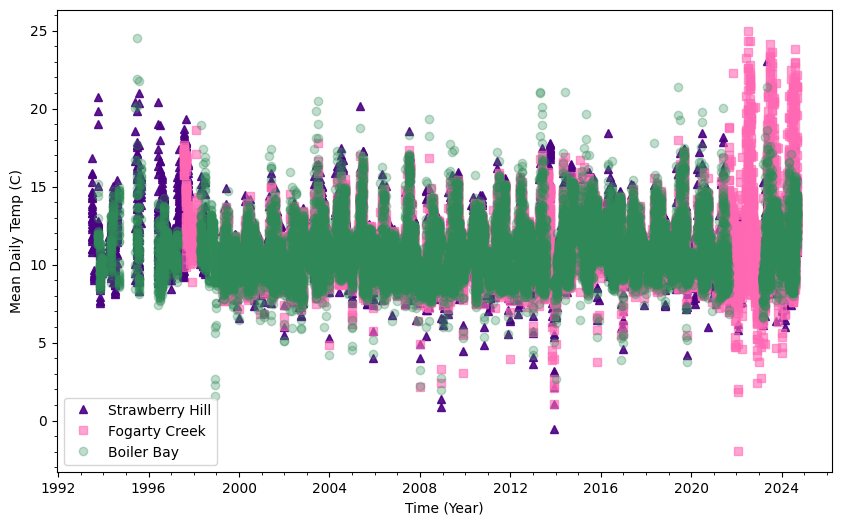

In [38]:
# Plot Mean Temp against Time for visual check
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(10,6))

plt.plot(data[data[loc_col] == loc_1][x_col], data[data[loc_col] == loc_1][y_col], '^', alpha=0.9, color=colors[0], label=loc_1)
plt.plot(data[data[loc_col] == loc_2][x_col], data[data[loc_col] == loc_2][y_col], 's', alpha=0.6, color=colors[1], label=loc_2)
plt.plot(data[data[loc_col] == loc_3][x_col], data[data[loc_col] == loc_3][y_col], 'o', alpha=0.3, color=colors[2], label=loc_3)

plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.xlabel("Time (Year)")
plt.ylabel("Mean Daily Temp (C)")

plt.legend()
plt.minorticks_on()
plt.show()

**FIGURE 1:**
Scatter plot showing coral cover over time in the Barnards and Barren reefs.
This plot was created to visualise any potential trends in the dataset, and the differences between the two reefs, before we applied any further statistical analysis.

We scaled the dataset so that the models sampled more reliably and were more efficent.

In [37]:
# Scale the x variable (Time), so it has a mean of 0 and standard deviation of 1
data["x_scaled"] = (data[x_col] - np.mean(data[x_col])) / np.std(data[x_col])

# Create polynomial terms for testing increasingly complex regression models
data["x2_scaled"] = data["x_scaled"] ** 2
data["x3_scaled"] = data["x_scaled"] ** 3
data["x4_scaled"] = data["x_scaled"] ** 4

We added polynomial terms to allow for curved relationships, and compared the fitted models.

In [39]:
# Fit a straight-line model (first-order polynomial)
model_linear = bmb.Model(f"{y_col} ~ x_scaled * {loc_col}", data)
idata_linear = model_linear.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a quadratic model (second-order polynomial)
model_quadratic = bmb.Model(f"{y_col} ~ x_scaled + x2_scaled * {loc_col}", data)
idata_quadratic = model_quadratic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a cubic model (third-order polynomial)
model_cubic = bmb.Model(f"{y_col} ~ x_scaled + x2_scaled + x3_scaled * {loc_col}", data)
idata_cubic = model_cubic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a quartic model (fourth-order polynomial)
model_quartic = bmb.Model(f"{y_col} ~ x_scaled + x2_scaled + x3_scaled + x4_scaled * {loc_col}", data)
idata_quartic = model_quartic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  ret

In [ ]:
# Compare all fitted models using Arviz model comparison
# The model with rank 0 is considered the best-fitting model

az.compare({"linear": idata_linear, "quadratic": idata_quadratic, "cubic": idata_cubic, "quartic": idata_quartic})

The model comparison indicated that the cubic model (wtih rank 0) was the best fit for the relationship between year and coral cover score across the two selected locations.

We plotted out initial asssumptions of the data.


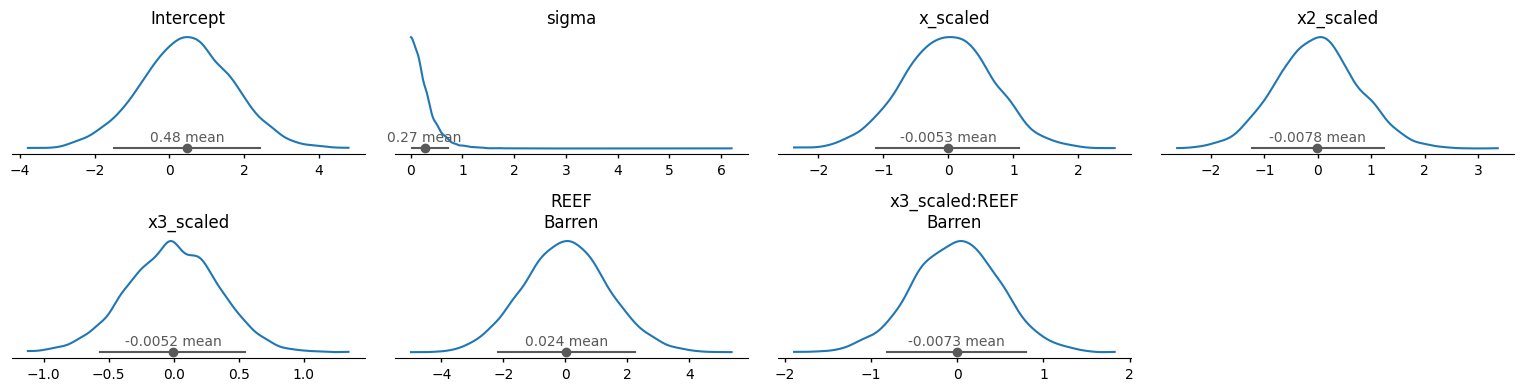

In [ ]:
#EMILY CODED DATA VISUALISATION AND INTERPRETATION

  #FOR OUR CHOSEN CUBIC MODEL:

#Plot the priors used by bambi
model_cubic.plot_priors()
plt.tight_layout() #So the plots don't overlap
plt.show()

**FIGURE 2:**
The priors are rather broad and centred around 0, which indicates that there might not be a strong relationship between year and coral cover.

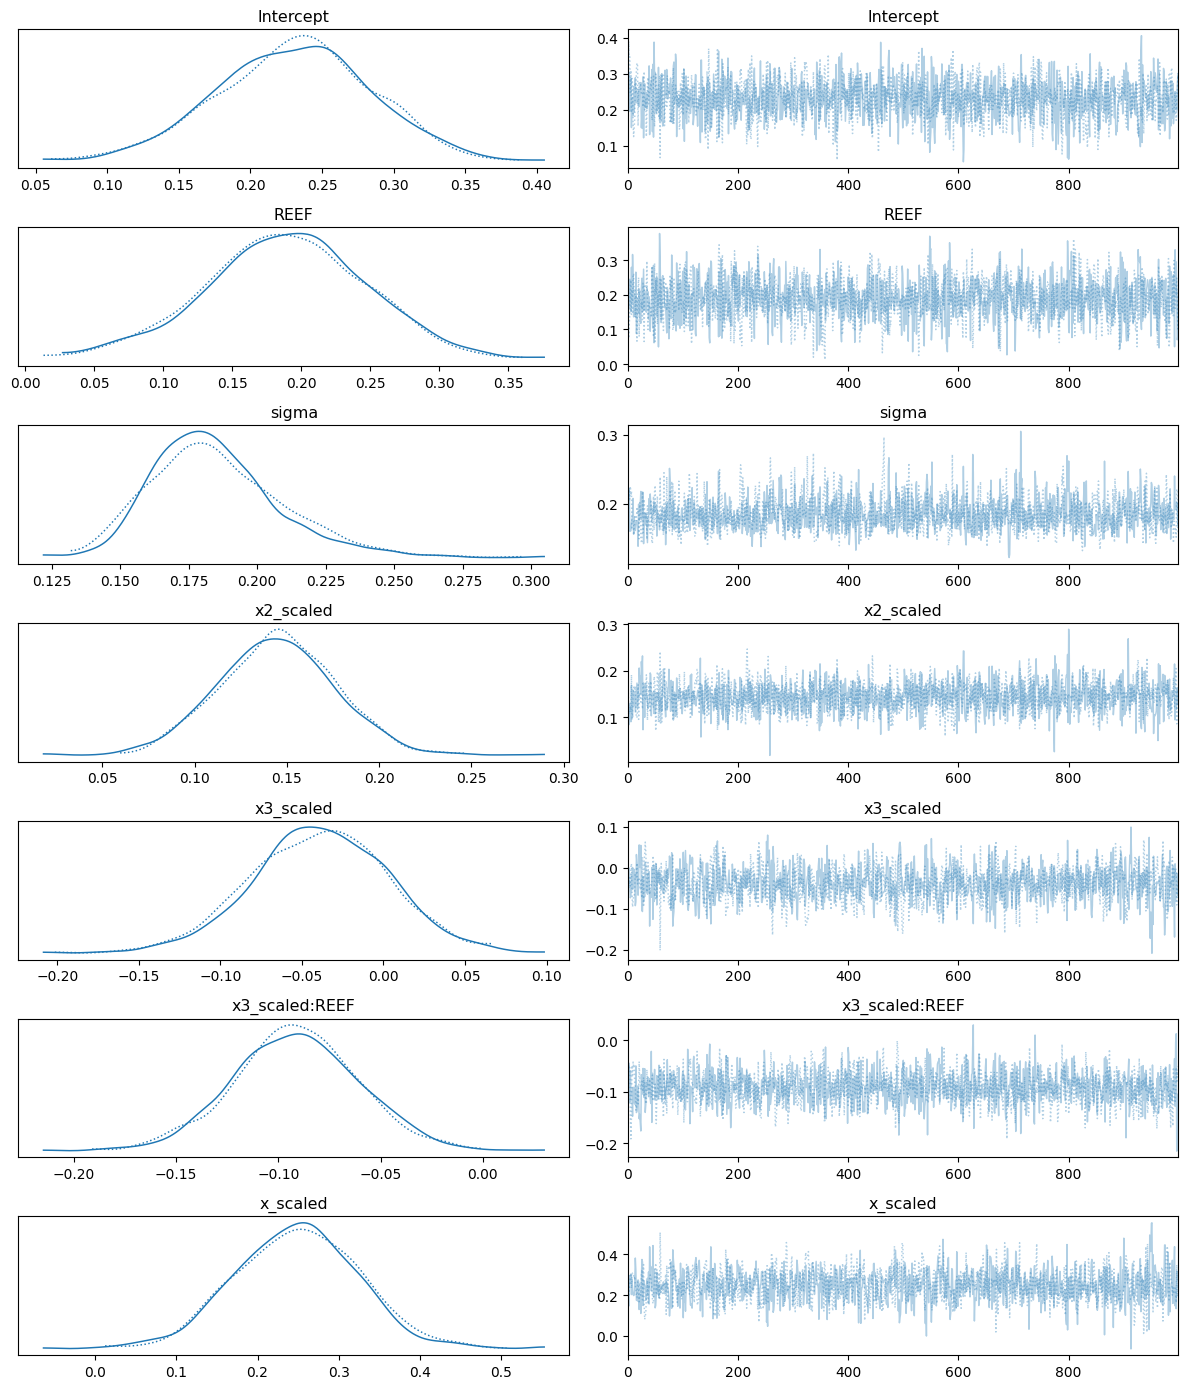

In [ ]:
#Use arviz to plot the sampled posterior distributions
az.plot_trace(idata_cubic);
plt.tight_layout() #To prevent the plots from overlapping

**FIGURE 3:**
Posterior distributions for the regression models
The plots help to show that our data is reliable, as the MCMC chains have good overlap and converge.

We created a graph of our models, including HDIs and the observed reef data.

In [40]:
  #CREATE PREDICTIVE RANGES FOR OUR MODEL

x_range = np.linspace(data[x_col].min(), data[x_col].max(), 1000)
x_range_scaled = (x_range - np.mean(data[x_col])) / np.std(data[x_col])

x2_range_scaled = x_range_scaled ** 2
x3_range_scaled = x_range_scaled ** 3

# Predictions for location 1
new_data_loc1 = pd.DataFrame({"x_scaled": x_range_scaled, "x2_scaled": x2_range_scaled, "x3_scaled": x3_range_scaled, loc_col: loc_1})
idata_predictions_loc1_params = model_cubic.predict(idata_cubic, data=new_data_loc1, kind='response_params', inplace=False)
idata_predictions_loc1_response = model_cubic.predict(idata_cubic, data=new_data_loc1, kind='response', inplace=False)
y_col_mean_draws_loc1 = idata_predictions_loc1_params.posterior["mu"].values.reshape(-1, len(x_range))
y_col_pps_draws_loc1 = idata_predictions_loc1_response.posterior_predictive[y_col].values.reshape(-1, len(x_range))
posterior_mean_loc1 = y_col_pps_draws_loc1.mean(axis=0)
hdi_mean_loc1 = az.hdi(y_col_mean_draws_loc1, prob=0.95)
hdi_pps_loc1 = az.hdi(y_col_pps_draws_loc1, prob=0.95)

# Predictions for location 2
new_data_loc2 = pd.DataFrame({"x_scaled": x_range_scaled, "x2_scaled": x2_range_scaled, "x3_scaled": x3_range_scaled, loc_col: loc_2})
idata_predictions_loc2_params = model_cubic.predict(idata_cubic, data=new_data_loc2, kind='response_params', inplace=False)
idata_predictions_loc2_response = model_cubic.predict(idata_cubic, data=new_data_loc2, kind='response', inplace=False)
y_mean_draws_loc2 = idata_predictions_loc2_params.posterior["mu"].values.reshape(-1, len(x_range))
y_pps_draws_loc2 = idata_predictions_loc2_response.posterior_predictive[y_col].values.reshape(-1, len(x_range))
posterior_mean_loc2 = y_pps_draws_loc2.mean(axis=0)
hdi_mean_loc2 = az.hdi(y_mean_draws_loc2, prob=0.95)
hdi_pps_loc2 = az.hdi(y_pps_draws_loc2, prob=0.95)

# Predictions for location 3
new_data_loc3 = pd.DataFrame({"x_scaled": x_range_scaled, "x2_scaled": x2_range_scaled, "x3_scaled": x3_range_scaled, loc_col: loc_3})
idata_predictions_loc3_params = model_cubic.predict(idata_cubic, data=new_data_loc3, kind='response_params', inplace=False)
idata_predictions_loc3_response = model_cubic.predict(idata_cubic, data=new_data_loc3, kind='response', inplace=False)
y_mean_draws_loc3 = idata_predictions_loc3_params.posterior["mu"].values.reshape(-1, len(x_range))
y_pps_draws_loc3 = idata_predictions_loc3_response.posterior_predictive[y_col].values.reshape(-1, len(x_range))
posterior_mean_loc3 = y_pps_draws_loc3.mean(axis=0)
hdi_mean_loc3 = az.hdi(y_mean_draws_loc3, prob=0.95)
hdi_pps_loc3 = az.hdi(y_pps_draws_loc3, prob=0.95)

plt.figure(figsize=(12, 7))
locations = [loc_1, loc_2, loc_3]
means = [posterior_mean_loc1, posterior_mean_loc2, posterior_mean_loc3]
hdis_m = [hdi_mean_loc1, hdi_mean_loc2, hdi_mean_loc3]
hdis_p = [hdi_pps_loc1, hdi_pps_loc2, hdi_pps_loc3]

for i in range(3):
    plt.plot(data[data[loc_col] == locations[i]][x_col], data[data[loc_col] == locations[i]][y_col], 'o', color=colors[i], label=f'{locations[i]} Obs', alpha=0.3)
    plt.plot(x_range, means[i], color=colors[i], label=f'{locations[i]} Mean')
    plt.fill_between(x_range, hdis_m[i][:,0], hdis_m[i][:,1], alpha=0.2, color=colors[i])

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Time (Year)")
plt.ylabel("Mean Daily Temp (C)")
plt.show()

TypeError: hdi got an unexpected keyword argument: 'hdi_prob'

**FIGURE 4:**
Overall, the data - particularly for Barnards - seem to be fairly well explained by our cubic model. The relationship here shows coverage for both reefs reaching a minimum around 2010-2011, then increasing until about 2021. From this model, we can see a similarity in the variation in reef coverage for the wet tropics and Fitzroy regions, which indicates that they may be affected by some of the same factors (e.g. temperature, pH of the ocean off the Queensland coast). The negative predictive values are acknowledged as a limitation of our model, and have been eliminated as it is not possible to have less than zero reef coverage.

**FURTHER NOTES:**
 - The posterior represents the model's best estimation of coral cover and the HDI represents the range in which the true value is likely to lie.
 - However the model was limited in that there was an increasing uncertainty as the models moved out towards the unobserved range.

How accurate do we think this model is?

In [41]:
# EXTRAPOLATION

x_range = np.linspace(data[x_col].min(), 2040, 1000)
x_range_scaled = (x_range - np.mean(data[x_col])) / np.std(data[x_col])
x2_range_scaled = x_range_scaled ** 2
x3_range_scaled = x_range_scaled ** 3

# Predictions for extrapolation
new_data_loc1 = pd.DataFrame({"x_scaled": x_range_scaled, "x2_scaled": x2_range_scaled, "x3_scaled": x3_range_scaled, loc_col: loc_1})
idata_predictions_loc1_params = model_cubic.predict(idata_cubic, data=new_data_loc1, kind='response_params', inplace=False)
y_col_mean_draws_loc1 = idata_predictions_loc1_params.posterior["mu"].values.reshape(-1, len(x_range))
hdi_mean_loc1 = az.hdi(y_col_mean_draws_loc1, prob=0.95)

new_data_loc2 = pd.DataFrame({"x_scaled": x_range_scaled, "x2_scaled": x2_range_scaled, "x3_scaled": x3_range_scaled, loc_col: loc_2})
idata_predictions_loc2_params = model_cubic.predict(idata_cubic, data=new_data_loc2, kind='response_params', inplace=False)
y_mean_draws_loc2 = idata_predictions_loc2_params.posterior["mu"].values.reshape(-1, len(x_range))
hdi_mean_loc2 = az.hdi(y_mean_draws_loc2, prob=0.95)

new_data_loc3 = pd.DataFrame({"x_scaled": x_range_scaled, "x2_scaled": x2_range_scaled, "x3_scaled": x3_range_scaled, loc_col: loc_3})
idata_predictions_loc3_params = model_cubic.predict(idata_cubic, data=new_data_loc3, kind='response_params', inplace=False)
y_mean_draws_loc3 = idata_predictions_loc3_params.posterior["mu"].values.reshape(-1, len(x_range))
hdi_mean_loc3 = az.hdi(y_mean_draws_loc3, prob=0.95)

plt.figure(figsize=(12, 7))
locations = [loc_1, loc_2, loc_3]
hdis_m = [hdi_mean_loc1, hdi_mean_loc2, hdi_mean_loc3]
means = [y_col_mean_draws_loc1.mean(axis=0), y_mean_draws_loc2.mean(axis=0), y_mean_draws_loc3.mean(axis=0)]

for i in range(3):
    plt.plot(x_range, means[i], color=colors[i], label=f'{locations[i]} Extrapolated')
    plt.fill_between(x_range, hdis_m[i][:,0], hdis_m[i][:,1], alpha=0.1, color=colors[i])

plt.axhline(y=0, color="black", linestyle=":")
plt.xlabel("Year")
plt.ylabel("Mean Daily Temperature (C)")
plt.title("Cubic Regression Model Extrapolated to 2040")
plt.show()

TypeError: hdi got an unexpected keyword argument: 'hdi_prob'

**FIGURE 5:**
This graph was created by extending the predictions to 2040. According to our cubic model, Barnards reef coverage may either increase or decrease while Barren will continue to decrease over the 16-year period beyond the data observations. We know that climate factors are decreasing reef coverage in general; however, this model allows for only limited variation in coverage, and so may not be practicable for long-term predictions. A continuous downward trend might not encapsulate the complexity of factors impacting coverage - for example, insolation impacts reef health and varies according to a cycle.

A more accurate model would be asymptotic, or would give a constant predicted mean of zero beyond the x-intercept shown. However, if we ignore the negative predictions for reef coverage scores, we can see that what our model does a good job of is showing the variation in coverage over the period we are looking at, and predicting a general trend.

**Week 8 Group Project Reflections:**